In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style='whitegrid')

In [2]:
df = pd.read_excel("../data/Dataset_complet_Meteo.xlsx")

print("Shape:", df.shape)
df.head()

Shape: (87240, 26)


,id,time,weather_code,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,sunrise,...,precipitation_hours,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,shortwave_radiation_sum,et0_fao_evapotranspiration,city,region,latitude,longitude
0,1,2020-01-01,3,33.2,2026-09-21 00:00:00,2026-05-26 00:00:00,34.0,2026-06-25 00:00:00,2026-01-29 00:00:00,2020-01-01 06:22:00,...,0.0,2026-05-10 00:00:00,2026-05-24 00:00:00,132,20.18,4.59,Bafia,Centre,4.75,11.23
1,2,2020-01-02,3,31.9,2026-09-21 00:00:00,2026-09-25 00:00:00,2026-01-31 00:00:00,2026-03-23 00:00:00,27.0,2020-01-02 06:23:00,...,0.0,2026-05-08 00:00:00,2026-06-25 00:00:00,77,19.39,4.64,Bafia,Centre,4.75,11.23
2,3,2020-01-03,3,32.0,2026-03-19 00:00:00,25.0,2026-07-31 00:00:00,2026-02-19 00:00:00,2026-01-25 00:00:00,2020-01-03 06:23:00,...,0.0,2026-09-08 00:00:00,2026-09-25 00:00:00,65,2026-03-20 00:00:00,4.78,Bafia,Centre,4.75,11.23
3,4,2020-01-04,3,2026-05-31 00:00:00,2026-01-19 00:00:00,2026-07-24 00:00:00,32.3,2026-07-20 00:00:00,2026-04-25 00:00:00,2020-01-04 06:24:00,...,0.0,2026-02-11 00:00:00,2026-02-20 00:00:00,106,20.48,4.59,Bafia,Centre,4.75,11.23
4,5,2020-01-05,3,31.9,2026-03-19 00:00:00,2026-08-24 00:00:00,33.1,2026-03-20 00:00:00,2026-09-25 00:00:00,2020-01-05 06:24:00,...,0.0,2026-03-11 00:00:00,2026-08-23 00:00:00,100,19.98,4.39,Bafia,Centre,4.75,11.23


In [3]:
#Show column names
df.columns

Index(['id', 'time', 'weather_code', 'temperature_2m_max',
       'temperature_2m_min', 'temperature_2m_mean', 'apparent_temperature_max',
       'apparent_temperature_min', 'apparent_temperature_mean', 'sunrise',
       'sunset', 'daylight_duration', 'sunshine_duration', 'precipitation_sum',
       'rain_sum', 'snowfall_sum', 'precipitation_hours', 'wind_speed_10m_max',
       'wind_gusts_10m_max', 'wind_direction_10m_dominant',
       'shortwave_radiation_sum', 'et0_fao_evapotranspiration', 'city',
       'region', 'latitude', 'longitude'],
      dtype='object')

In [4]:
#Data info
df.info()
df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87240 entries, 0 to 87239
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id                           87240 non-null  int64         
 1   time                         87240 non-null  datetime64[ns]
 2   weather_code                 87240 non-null  int64         
 3   temperature_2m_max           87240 non-null  object        
 4   temperature_2m_min           87240 non-null  object        
 5   temperature_2m_mean          87240 non-null  object        
 6   apparent_temperature_max     87240 non-null  object        
 7   apparent_temperature_min     87240 non-null  object        
 8   apparent_temperature_mean    87240 non-null  object        
 9   sunrise                      87240 non-null  datetime64[ns]
 10  sunset                       87240 non-null  datetime64[ns]
 11  daylight_duration            87240 non-nu

,id,time,weather_code,sunrise,sunset,daylight_duration,snowfall_sum,precipitation_hours,wind_direction_10m_dominant
count,87240.0,87240,87240.00,87240,87240,87240.00,87240.0,87240.00,87240.00
mean,2617.7,2022-12-26 00:00:00.000000256,40.56,2022-12-26 06:08:23.672626944,2022-12-26 18:15:49.028885760,43645.37,0.0,5.88,185.37
min,1.0,2020-01-01 00:00:00,0.00,2020-01-01 06:05:00,2020-01-01 17:45:00,41097.38,0.0,0.00,0.00
25%,1148.0,2021-06-29 00:00:00,3.00,2021-06-29 05:52:45,2021-06-29 18:25:45,42970.90,0.0,0.00,108.00
50%,2318.0,2022-12-26 00:00:00,51.00,2022-12-26 06:19:00,2022-12-26 18:11:00,43640.32,0.0,4.00,210.00
75%,3681.0,2024-06-23 00:00:00,61.00,2024-06-23 06:09:00,2024-06-23 18:34:00,44318.55,0.0,10.00,260.00
max,8724.0,2025-12-20 00:00:00,65.00,2025-12-20 06:26:00,2025-12-20 18:17:00,46198.17,0.0,24.00,360.00
std,1880.4,NaN,25.74,NaN,NaN,912.38,0.0,6.05,95.20


In [5]:
#Convert numeric columns and data cleaning
num_cols = [
    'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
    'apparent_temperature_mean', 'precipitation_sum', 'rain_sum',
    'wind_speed_10m_max', 'wind_gusts_10m_max',
    'shortwave_radiation_sum', 'et0_fao_evapotranspiration',
    'sunshine_duration', 'latitude', 'longitude'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [6]:
#Time features
df['time'] = pd.to_datetime(df['time'])

df['month'] = df['time'].dt.month
df['day_of_year'] = df['time'].dt.dayofyear

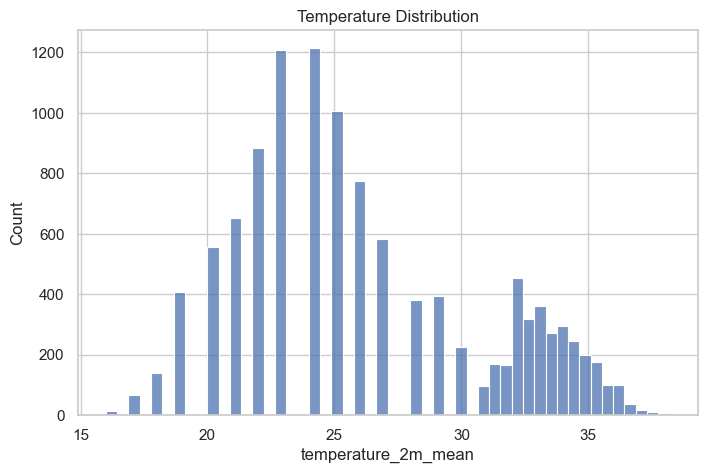

In [7]:
#Temperature distribution
plt.figure(figsize=(8,5))
sns.histplot(df['temperature_2m_mean'], bins=50)
plt.title("Temperature Distribution")
plt.show()

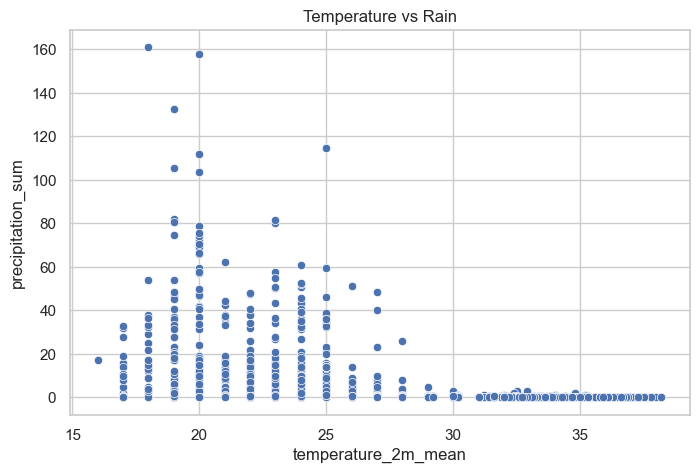

In [8]:
#Rain vs Temperature
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['temperature_2m_mean'], y=df['precipitation_sum'])
plt.title("Temperature vs Rain")
plt.show()

In [9]:
#Feature engeneering

df['temp_amplitude'] = df['temperature_2m_max'] - df['temperature_2m_min']
df['sunshine_ratio'] = df['sunshine_duration'] / (24 * 3600)

df['is_no_wind'] = (df['wind_speed_10m_max'] < 1).astype(int)
df['is_no_rain'] = (df['precipitation_sum'] == 0).astype(int)

df['is_dry_season'] = df['month'].isin([12, 1, 2]).astype(int)

In [10]:
#Create Pollution Target
df['pm25_proxy'] = (
    0.35 * df['temperature_2m_mean'].fillna(df['temperature_2m_mean'].mean())
    + 0.25 * df['shortwave_radiation_sum'].fillna(0)
    + 0.20 * df['et0_fao_evapotranspiration'].fillna(0)
    + 8.0  * df['is_no_wind']
    + 5.0  * df['is_no_rain']
    + 4.0  * df['is_dry_season']
).clip(lower=0)

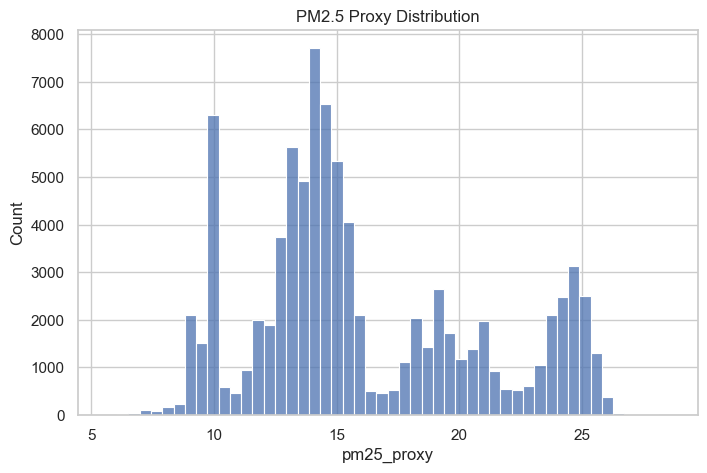

In [11]:
#Pollution distribution
plt.figure(figsize=(8,5))
sns.histplot(df['pm25_proxy'], bins=50)
plt.title("PM2.5 Proxy Distribution")
plt.show()

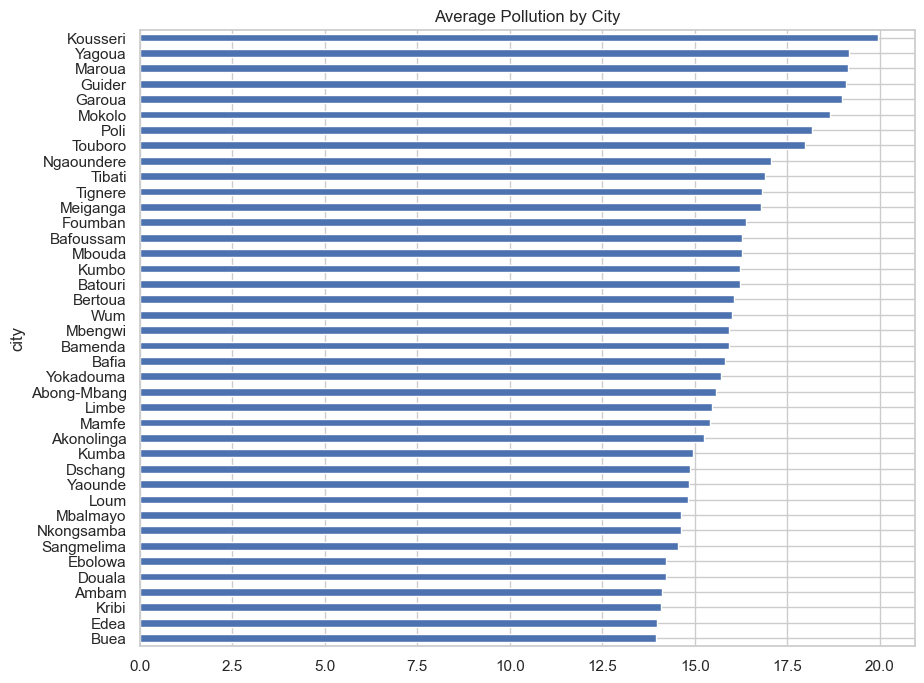

In [12]:
#Pollution by City

city_pollution = df.groupby('city')['pm25_proxy'].mean().sort_values()

plt.figure(figsize=(10,8))
city_pollution.plot(kind='barh')
plt.title("Average Pollution by City")
plt.show()

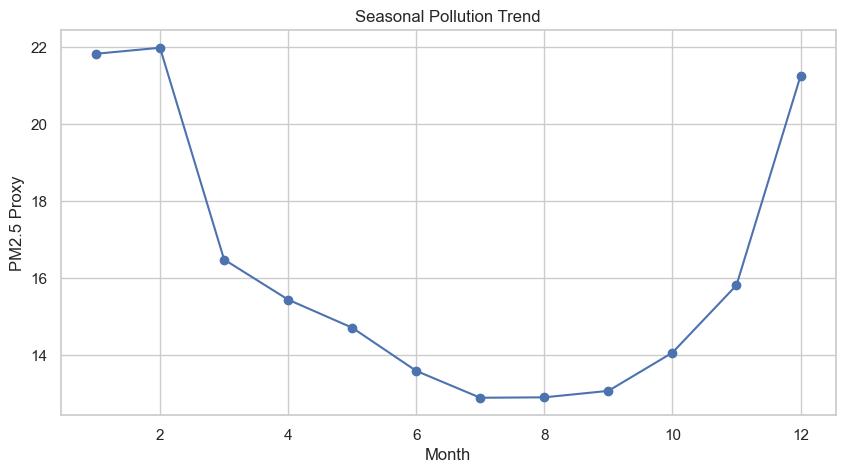

In [13]:
#Seasonality

monthly = df.groupby('month').agg(
    temp_mean=('temperature_2m_mean', 'mean'),
    rain_mean=('precipitation_sum', 'mean'),
    pollution_mean=('pm25_proxy', 'mean')
)

plt.figure(figsize=(10,5))
plt.plot(monthly.index, monthly['pollution_mean'], marker='o')
plt.title("Seasonal Pollution Trend")
plt.xlabel("Month")
plt.ylabel("PM2.5 Proxy")
plt.show()

In [14]:
# map visualization

city_stats = df.groupby('city').agg(
    temp_mean=('temperature_2m_mean', 'mean'),
    pollution=('pm25_proxy', 'mean'),
    latitude=('latitude', 'first'),
    longitude=('longitude', 'first')
).reset_index()

fig = px.scatter_mapbox(
    city_stats,
    lat='latitude',
    lon='longitude',
    color='pollution',
    size='temp_mean',
    hover_name='city',
    color_continuous_scale='RdYlBu_r',
    zoom=3.8,
    mapbox_style='open-street-map',
    title="Air Pollution Map - Cameroon"
)

fig.show()

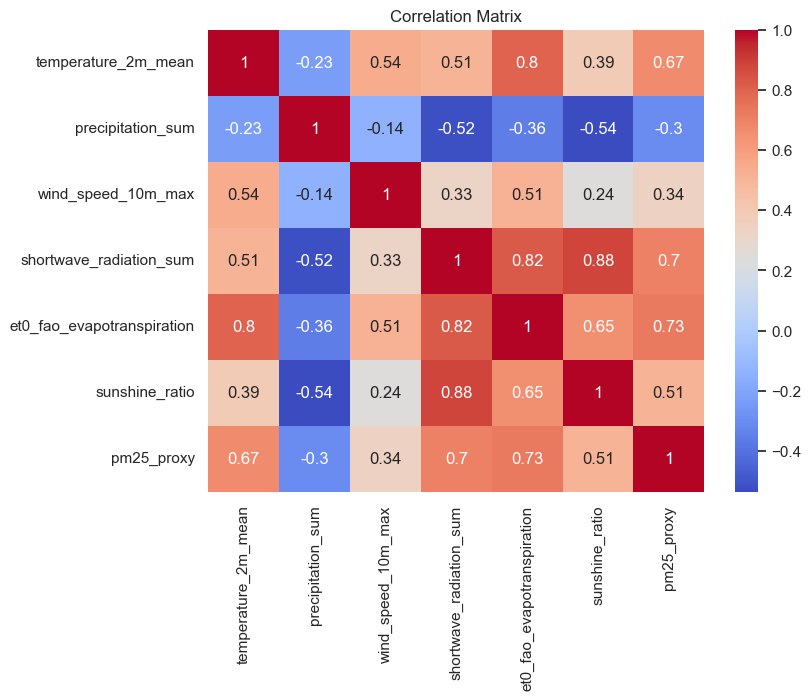

In [15]:
#Correlation heatmap


corr_cols = [
    'temperature_2m_mean',
    'precipitation_sum',
    'wind_speed_10m_max',
    'shortwave_radiation_sum',
    'et0_fao_evapotranspiration',
    'sunshine_ratio',
    'pm25_proxy'
]

plt.figure(figsize=(8,6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [17]:

# REQUIRED before df_model
df = df.sort_values(['city', 'time'])

# Cyclical encoding
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Lag features
df['temp_lag1'] = df.groupby('city')['temperature_2m_mean'].shift(1)
df['temp_lag7'] = df.groupby('city')['temperature_2m_mean'].shift(7)
df['wind_lag1'] = df.groupby('city')['wind_speed_10m_max'].shift(1)

df['temp_roll7'] = (
    df.groupby('city')['temperature_2m_mean']
    .rolling(7).mean()
    .reset_index(0, drop=True)
)

# Encoding
df['city_enc'] = df['city'].astype('category').cat.codes
df['region_enc'] = df['region'].astype('category').cat.codes

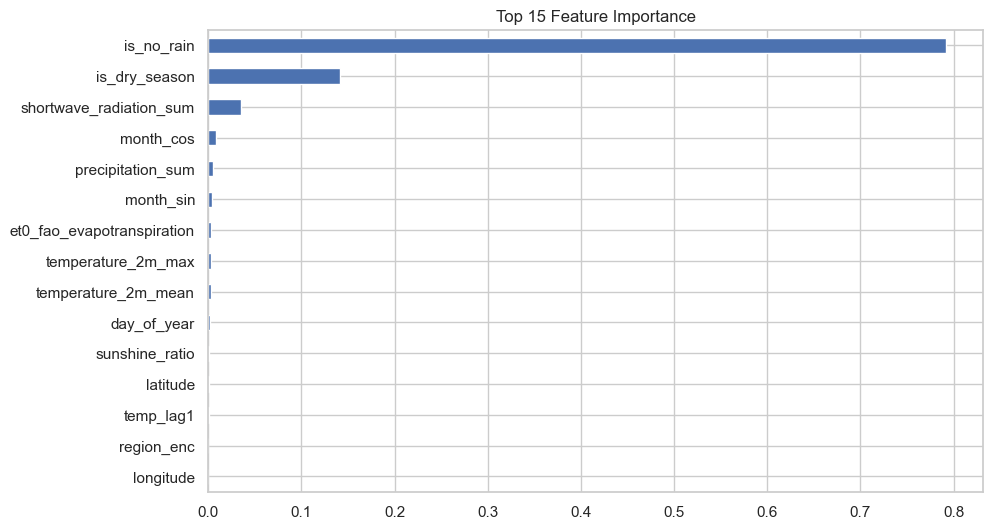

In [18]:
# ── Feature Importance ─────────────────────────────────────
import joblib

# Load model if it's not already loaded
if 'model' not in globals():
    model = joblib.load("../models/xgb_model.pkl")

# Define expected features (same as training)
FEATURES = [
    'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min',
    'precipitation_sum', 'wind_speed_10m_max', 'wind_gusts_10m_max',
    'shortwave_radiation_sum', 'et0_fao_evapotranspiration',
    'sunshine_ratio', 'temp_amplitude',
    'is_no_wind', 'is_no_rain', 'is_dry_season',
    'month_sin', 'month_cos', 'day_of_year',
    'temp_lag1', 'temp_lag7', 'wind_lag1', 'temp_roll7',
    'latitude', 'longitude', 'region_enc', 'city_enc'
]

# Rebuild test split if not already available
if 'X_test' not in globals() or 'y_test' not in globals():
    df_model = df[FEATURES + ['pm25_proxy']].copy()
    df_model = df_model.fillna(df_model.median())
    df_model = df_model.dropna(subset=['pm25_proxy'])
    split = int(len(df_model) * 0.8)
    X_test = df_model[FEATURES].iloc[split:]
    y_test = df_model['pm25_proxy'].iloc[split:]

importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.head(15).sort_values().plot(kind='barh')
plt.title("Top 15 Feature Importance")
plt.show()

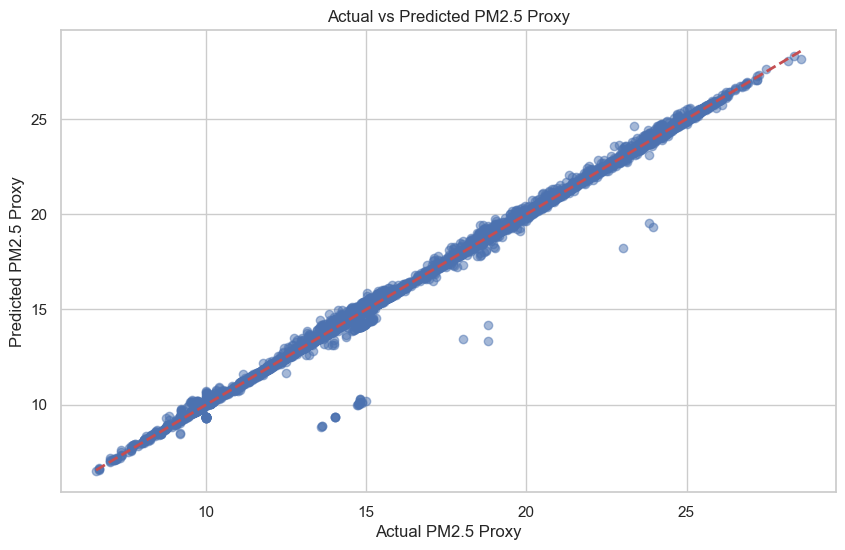

In [19]:
# ── Predictions vs Actual ─────────────────────────────
import joblib

if 'model' not in globals():
    model = joblib.load("../models/xgb_model.pkl")

if 'X_test' not in globals() or 'y_test' not in globals():
    df_model = df[FEATURES + ['pm25_proxy']].copy()
    df_model = df_model.fillna(df_model.median())
    df_model = df_model.dropna(subset=['pm25_proxy'])
    split = int(len(df_model) * 0.8)
    X_test = df_model[FEATURES].iloc[split:]
    y_test = df_model['pm25_proxy'].iloc[split:]

# make sure prediction exists
y_pred = model.predict(X_test)

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual PM2.5 Proxy')
plt.ylabel('Predicted PM2.5 Proxy')
plt.title('Actual vs Predicted PM2.5 Proxy')
plt.grid(True)
plt.show()

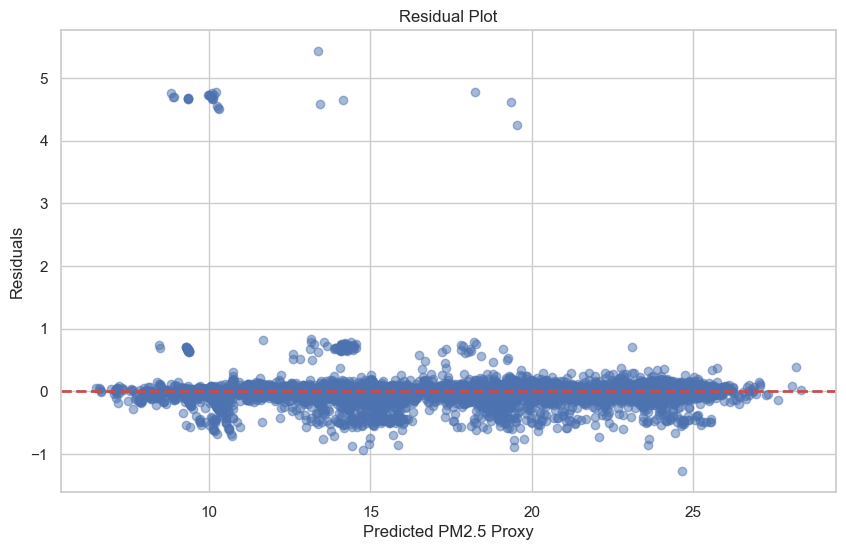

In [20]:
# ── Residual Plot ─────────────────────────────
if 'y_pred' not in globals():
    y_pred = model.predict(X_test)

residuals = y_test - y_pred

plt.figure(figsize=(10,6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted PM2.5 Proxy')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

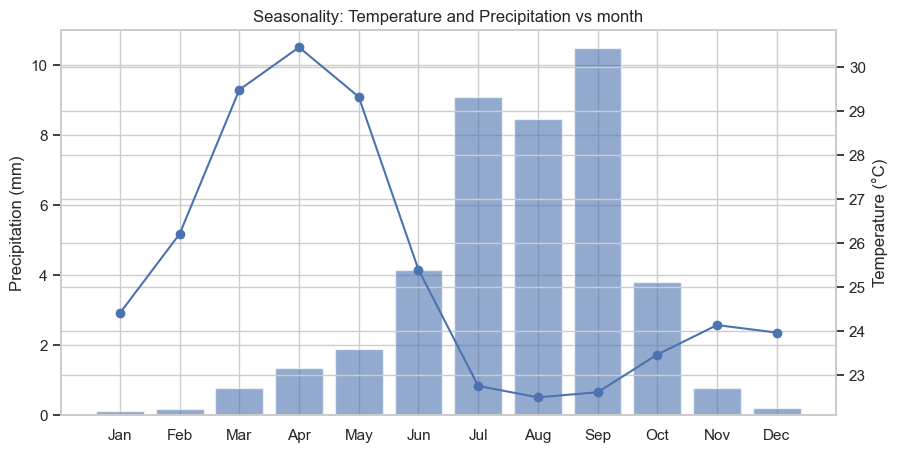

In [21]:
# ── Seasonality: Temperature & Precipitation ─────────────────

# Group by month
monthly = df.groupby('month').agg(
    temp_mean=('temperature_2m_mean', 'mean'),
    rain_mean=('precipitation_sum', 'mean')
)

# Plot
fig, ax1 = plt.subplots(figsize=(10,5))

months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

# Bar plot (rain)
ax1.bar(months, monthly['rain_mean'], alpha=0.6)
ax1.set_ylabel("Precipitation (mm)")

# Line plot (temperature)
ax2 = ax1.twinx()
ax2.plot(months, monthly['temp_mean'], marker='o')
ax2.set_ylabel("Temperature (°C)")

plt.title("Seasonality: Temperature and Precipitation vs month")

plt.show()

## Key Insights

- Pollution increases during dry season months
- Low wind speed strongly correlates with higher pollution
- Solar radiation contributes significantly to pollution proxy
- Certain cities show consistently higher pollution levels